# Business Growth Analysis

## Objective

Analyze Olist's business growth by studying:

- Revenue
- Orders
- Customers
- Sellers
- Average Order Value
- Monthly Growth
- Yearly Growth

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.style.use("ggplot")

In [2]:
master_df = pd.read_csv("../Data/master_dataset.csv")

In [4]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "review_creation_date",
    "review_answer_timestamp",
    "shipping_limit_date"
]

for col in date_cols:
    if col in master_df.columns:
        master_df[col] = pd.to_datetime(
            master_df[col],
            errors="coerce"
        )

In [5]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 48 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       119143 non-null  object        
 1   customer_id                    119143 non-null  object        
 2   order_status                   119143 non-null  object        
 3   order_purchase_timestamp       119143 non-null  datetime64[ns]
 4   order_approved_at              118966 non-null  datetime64[ns]
 5   order_delivered_carrier_date   117057 non-null  datetime64[ns]
 6   order_delivered_customer_date  115722 non-null  datetime64[ns]
 7   order_estimated_delivery_date  119143 non-null  datetime64[ns]
 8   purchase_year                  119143 non-null  int64         
 9   purchase_month                 119143 non-null  object        
 10  purchase_day                   119143 non-null  object        
 11  

# Business Question 1

## What is the overall business performance of Olist?

We begin by calculating the key business metrics that provide an overview of the marketplace's performance.

In [6]:
total_revenue = master_df["payment_value"].sum()
total_orders = master_df["order_id"].nunique()
total_customers = master_df["customer_unique_id"].nunique()
total_sellers = master_df["seller_id"].nunique()

average_order_value = (
    master_df.groupby("order_id")["payment_value"]
    .sum()
    .mean()
)

In [7]:
print("="*50)
print("OLIST BUSINESS KPIs")
print("="*50)

print(f"Total Revenue         : R$ {total_revenue:,.2f}")
print(f"Total Orders          : {total_orders:,}")
print(f"Total Customers       : {total_customers:,}")
print(f"Total Sellers         : {total_sellers:,}")
print(f"Average Order Value   : R$ {average_order_value:,.2f}")

OLIST BUSINESS KPIs
Total Revenue         : R$ 20,579,664.01
Total Orders          : 99,441
Total Customers       : 96,096
Total Sellers         : 3,095
Average Order Value   : R$ 206.95


# Business Question 2

## How has revenue changed over time?

In [8]:
monthly_revenue = (
    master_df
    .groupby(master_df["order_purchase_timestamp"].dt.to_period("M"))
    ["payment_value"]
    .sum()
)

In [9]:
monthly_revenue.head()

order_purchase_timestamp
2016-09       388.47
2016-10     76559.05
2016-12        19.62
2017-01    190806.27
2017-02    351848.13
Freq: M, Name: payment_value, dtype: float64

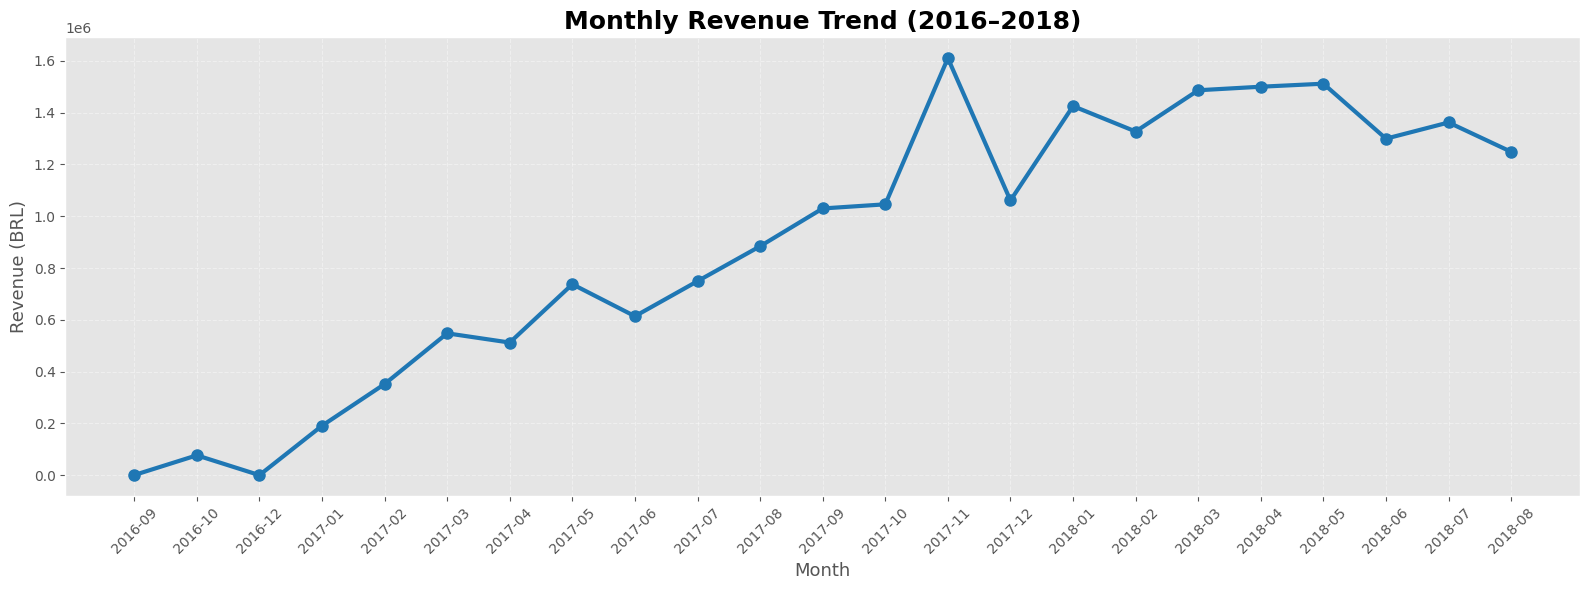

In [11]:
# Remove incomplete months
monthly_revenue = monthly_revenue.iloc[:-2]

plt.figure(figsize=(16,6))

plt.plot(
    monthly_revenue.index.astype(str),
    monthly_revenue.values,
    marker='o',
    linewidth=3,
    markersize=8,
    color='#1f77b4'
)

plt.title(
    "Monthly Revenue Trend (2016–2018)",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Month", fontsize=13)

plt.ylabel("Revenue (BRL)", fontsize=13)

plt.xticks(rotation=45)

plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()

plt.show()

# Business Question 3

## How has the number of orders changed over time?

Analyze the monthly order volume to understand customer demand and business growth.

In [12]:
monthly_orders = (
    master_df
    .groupby(master_df["order_purchase_timestamp"].dt.to_period("M"))
    ["order_id"]
    .nunique()
)

# Remove incomplete months
monthly_orders = monthly_orders.iloc[:-2]

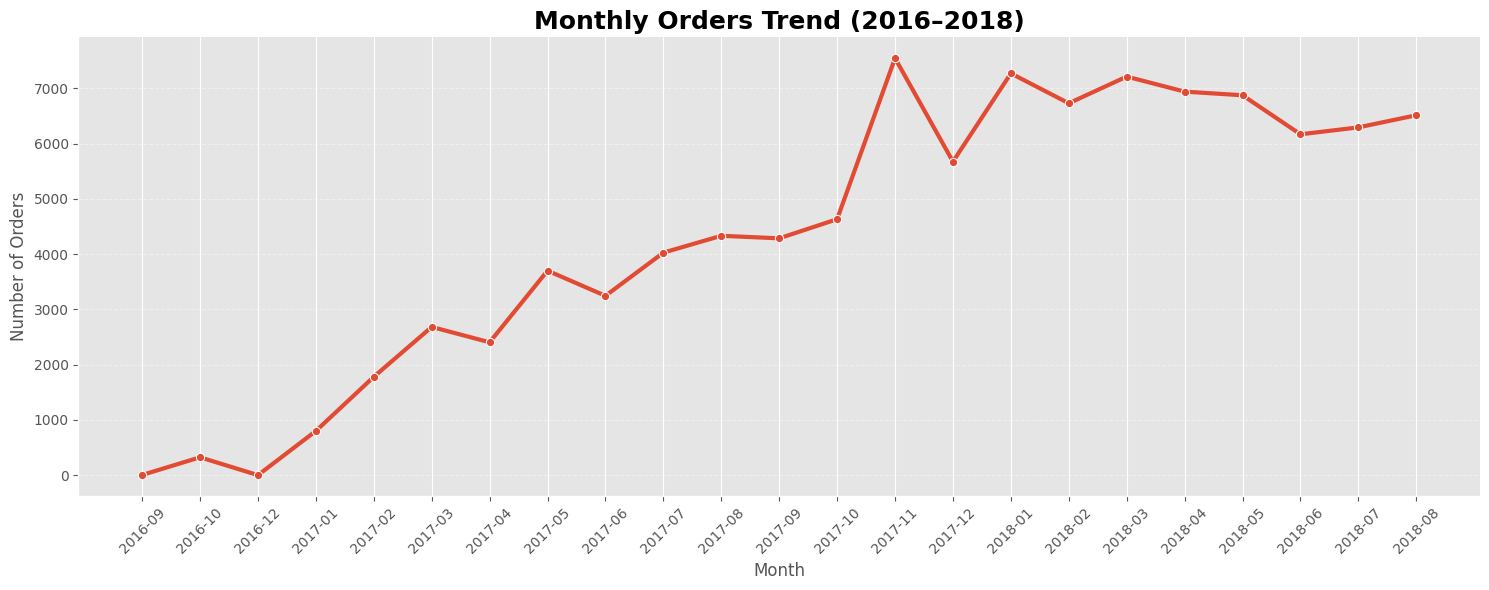

In [13]:
plt.figure(figsize=(15,6))

sns.lineplot(
    x=monthly_orders.index.astype(str),
    y=monthly_orders.values,
    marker="o",
    linewidth=3
)

plt.title("Monthly Orders Trend (2016–2018)", fontsize=18, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.4)
sns.despine()

plt.tight_layout()
plt.show()

### Business Insight

- Monthly order volume increased consistently from 2016 to 2018.
- Customer demand grew significantly throughout 2017.
- Order volume remained relatively stable at a high level during 2018.

### Recommendation

Plan inventory and logistics based on expected seasonal demand to maintain service quality during high-order months.

# Business Question 4

## Which months generate the highest revenue?

Understanding monthly revenue patterns helps identify seasonality and peak sales periods.

In [14]:
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

master_df["purchase_month"] = pd.Categorical(
    master_df["purchase_month"],
    categories=month_order,
    ordered=True
)

monthly_revenue = (
    master_df
    .groupby("purchase_month")["payment_value"]
    .sum()
    .reset_index()
)

monthly_revenue

,purchase_month,payment_value
0,January,1616267.67
1,February,1679187.10
2,March,2034439.48
3,April,2012499.64
4,May,2249436.06
5,June,1913460.58
6,July,2111509.92
7,August,2133110.99
8,September,1034969.98
9,October,1123232.13


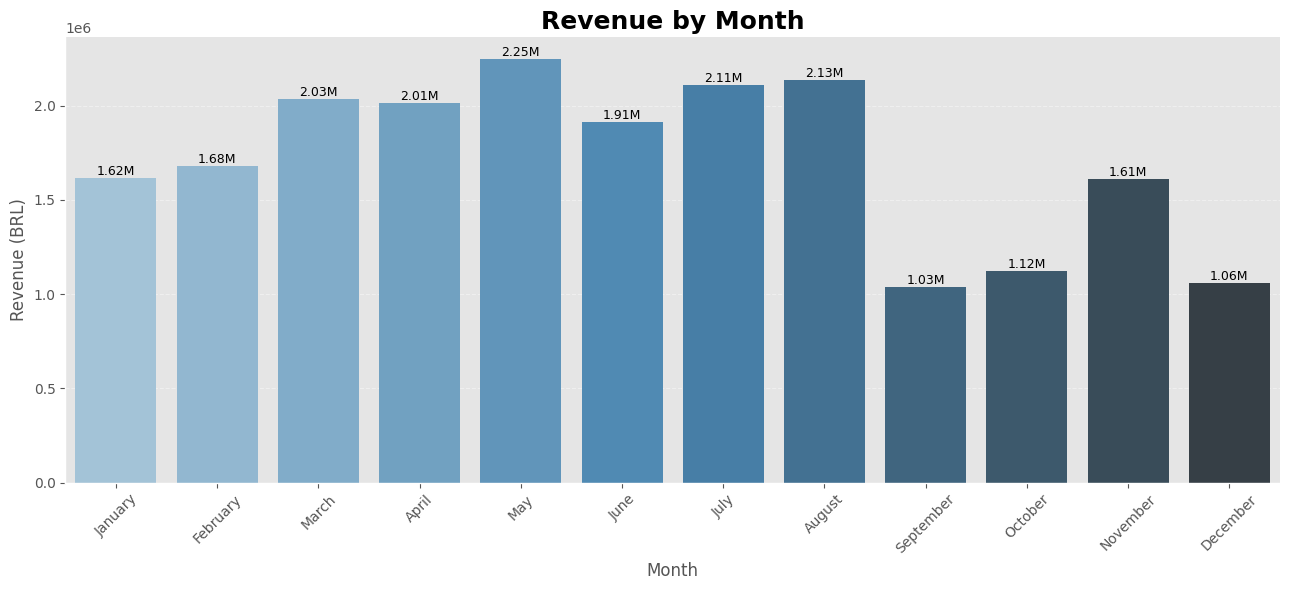

In [15]:
plt.figure(figsize=(13,6))

ax = sns.barplot(
    data=monthly_revenue,
    x="purchase_month",
    y="payment_value",
    palette="Blues_d"
)

plt.title(
    "Revenue by Month",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Revenue (BRL)")
plt.xticks(rotation=45)

# Add labels on bars
for p in ax.patches:
    ax.annotate(
        f'{p.get_height()/1e6:.2f}M',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# Business Question 5

## Which months receive the highest number of orders?

Analyzing monthly order volume helps identify demand patterns throughout the year.

In [16]:
monthly_orders = (
    master_df
    .groupby("purchase_month")["order_id"]
    .nunique()
    .reset_index()
)

monthly_orders

,purchase_month,order_id
0,January,8069
1,February,8508
2,March,9893
3,April,9343
4,May,10573
5,June,9412
6,July,10318
7,August,10843
8,September,4305
9,October,4959


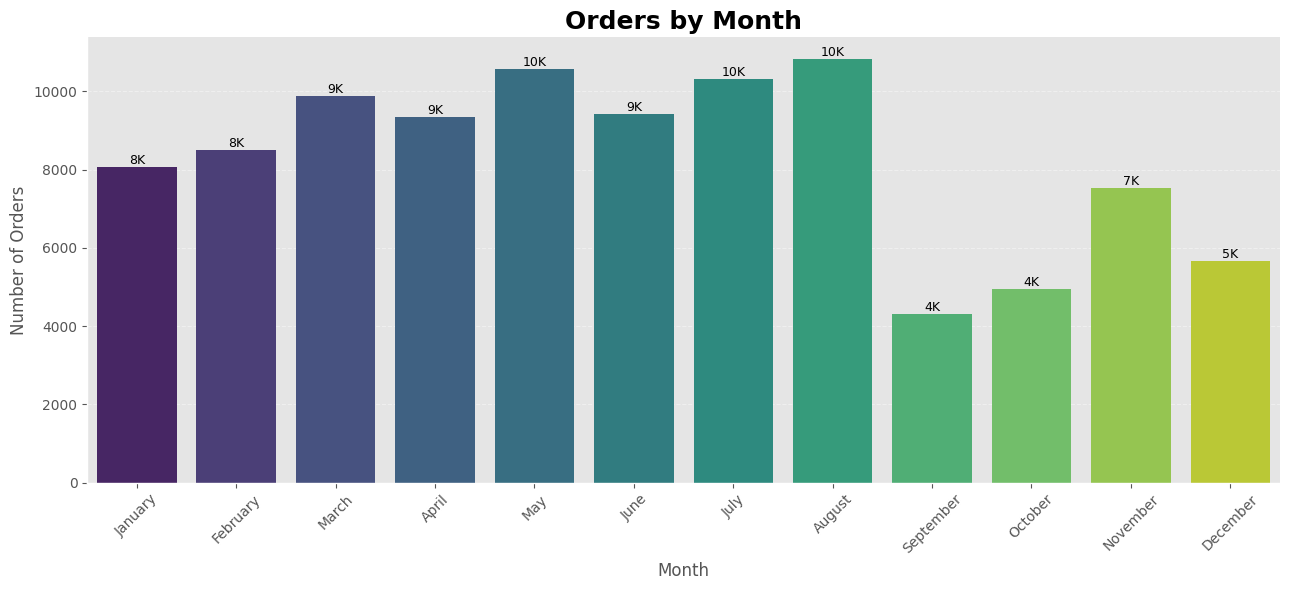

In [17]:
plt.figure(figsize=(13,6))

ax = sns.barplot(
    data=monthly_orders,
    x="purchase_month",
    y="order_id",
    palette="viridis"
)

plt.title(
    "Orders by Month",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()/1000)}K',
        (p.get_x()+p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=9
    )

sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# Business Question 6
# Revenue by Year

This will be our first executive-level KPI chart.

In [18]:
yearly_revenue = (
    master_df
    .groupby(master_df["order_purchase_timestamp"].dt.year)
    ["payment_value"]
    .sum()
    .reset_index()
)

yearly_revenue.columns = ["Year","Revenue"]

yearly_revenue

,Year,Revenue
0,2016,76967.14
1,2017,9334920.90
2,2018,11167775.97


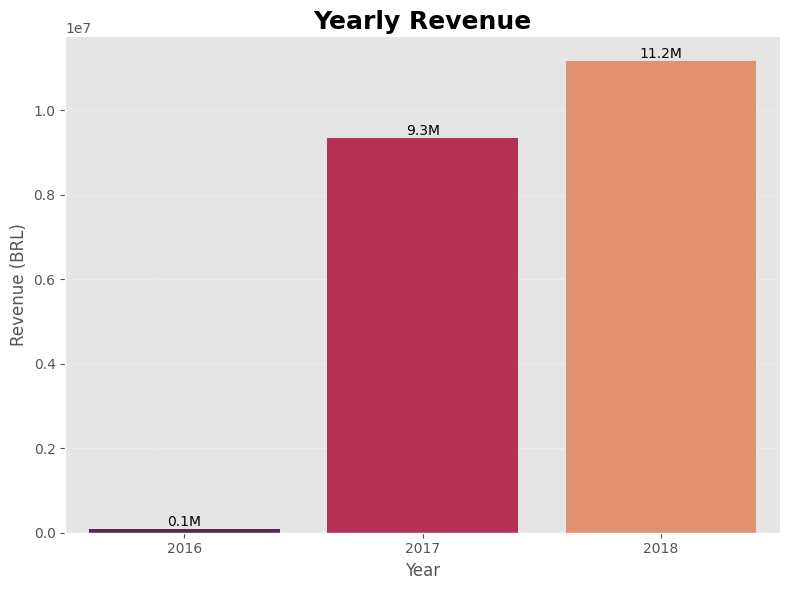

In [20]:
plt.figure(figsize=(8,6))

ax = sns.barplot(
    data=yearly_revenue,
    x="Year",
    y="Revenue",
    palette="rocket"
)

plt.title(
    "Yearly Revenue",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Revenue (BRL)")

for p in ax.patches:
    ax.annotate(
        f'{p.get_height()/1e6:.1f}M',
        (p.get_x()+p.get_width()/2,p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## # Customer Analysis ##

# Business Question 7

## Which states contribute the highest number of customers?

Understanding customer distribution helps identify major markets and regions with growth potential.

In [21]:
state_orders = (
    master_df
    .groupby("customer_state")["customer_unique_id"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
)

state_orders.head(10)

,customer_state,customer_unique_id
0,SP,40302
1,RJ,12384
2,MG,11259
3,RS,5277
4,PR,4882
5,SC,3534
6,BA,3277
7,DF,2075
8,ES,1964
9,GO,1952


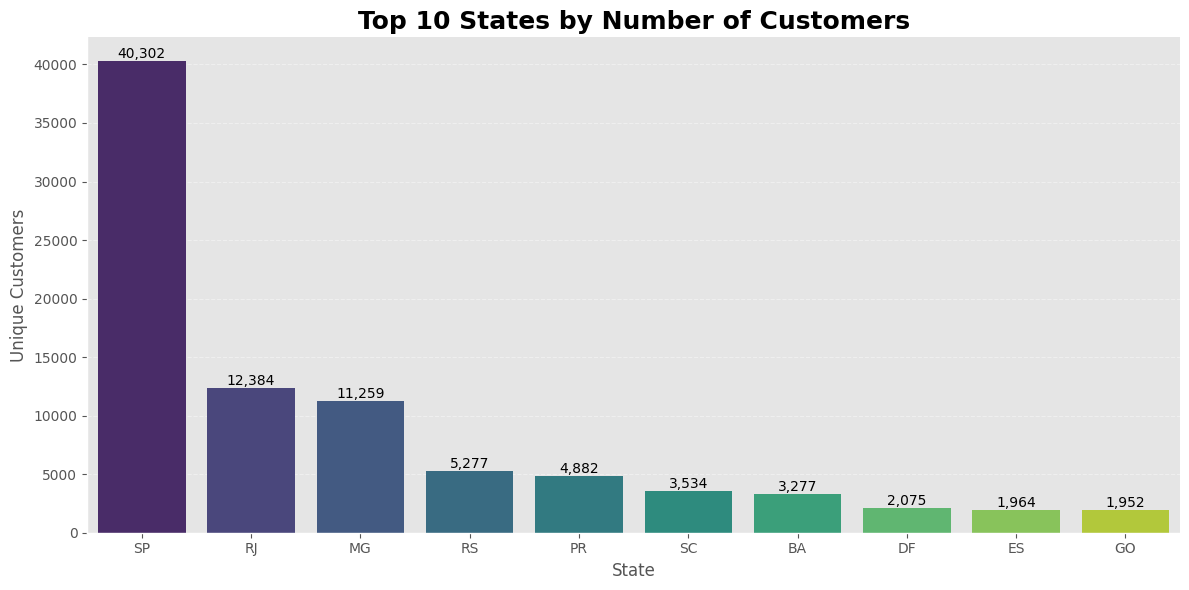

In [22]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=state_orders.head(10),
    x="customer_state",
    y="customer_unique_id",
    palette="viridis"
)

plt.title(
    "Top 10 States by Number of Customers",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("State")
plt.ylabel("Unique Customers")

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',
        (p.get_x()+p.get_width()/2,
         p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

sns.despine()

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

# Business Question 8

## Which cities contribute the highest number of customers?

In [23]:
customer_city = (
    master_df
    .groupby("customer_city")["customer_unique_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

customer_city

,customer_city,customer_unique_id
0,sao paulo,14984
1,rio de janeiro,6620
2,belo horizonte,2672
3,brasilia,2069
4,curitiba,1465
5,campinas,1398
6,porto alegre,1326
7,salvador,1209
8,guarulhos,1153
9,sao bernardo do campo,908


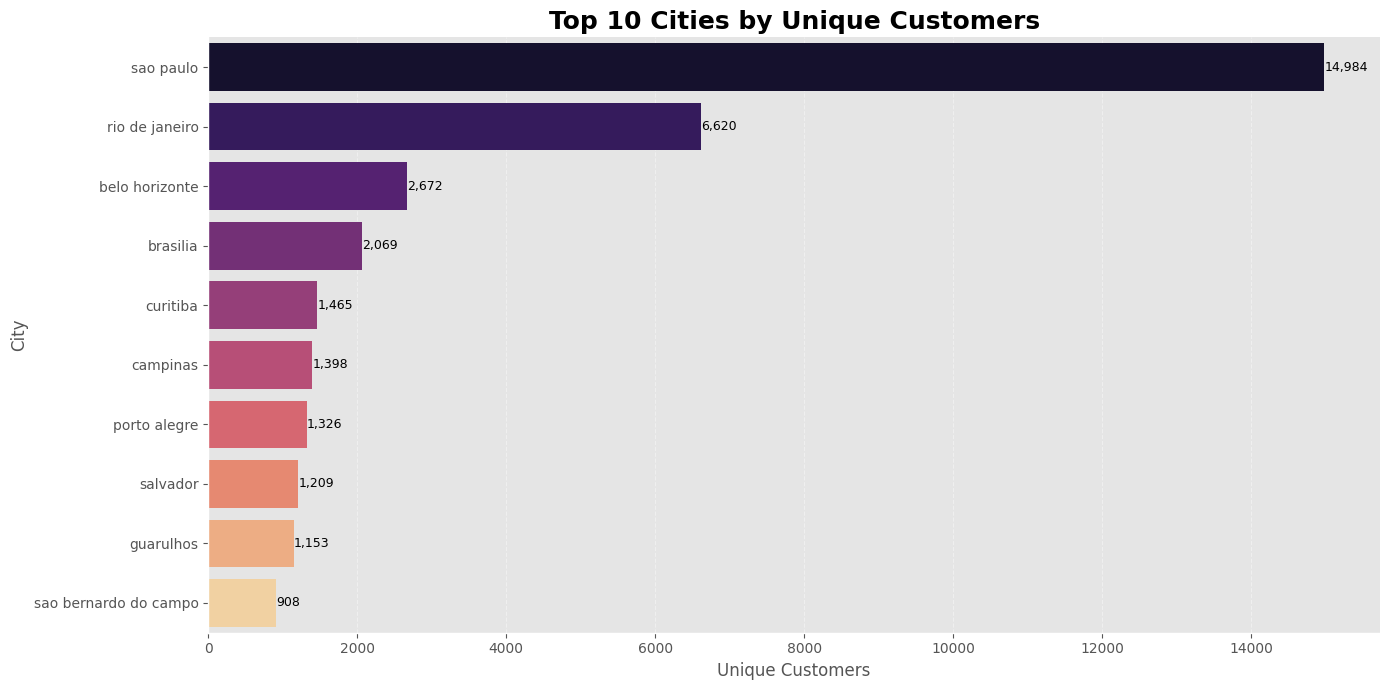

In [24]:
plt.figure(figsize=(14,7))

ax = sns.barplot(
    data=customer_city,
    y="customer_city",
    x="customer_unique_id",
    palette="magma"
)

plt.title(
    "Top 10 Cities by Unique Customers",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Unique Customers")
plt.ylabel("City")

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_width()):,}',
        (p.get_width(), p.get_y()+p.get_height()/2),
        ha="left",
        va="center",
        fontsize=9
    )

sns.despine()

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

# Business Question 9

## How many customers are repeat customers?

In [25]:
customer_orders = (
    master_df
    .groupby("customer_unique_id")["order_id"]
    .nunique()
)

customer_orders.head()

customer_unique_id
0000366f3b9a7992bf8c76cfdf3221e2    1
0000b849f77a49e4a4ce2b2a4ca5be3f    1
0000f46a3911fa3c0805444483337064    1
0000f6ccb0745a6a4b88665a16c9f078    1
0004aac84e0df4da2b147fca70cf8255    1
Name: order_id, dtype: int64

In [26]:
repeat = customer_orders.value_counts().sort_index()

repeat

order_id
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

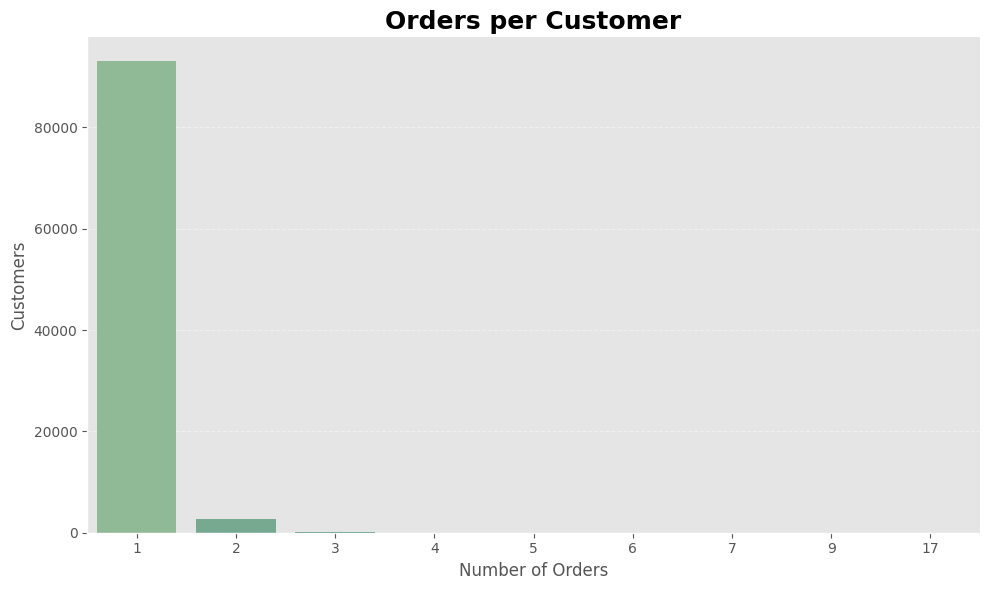

In [27]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=repeat.index.astype(str),
    y=repeat.values,
    palette="crest"
)

plt.title(
    "Orders per Customer",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Number of Orders")

plt.ylabel("Customers")

sns.despine()

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

# Business Question 10

## What is the distribution of customer order frequency?

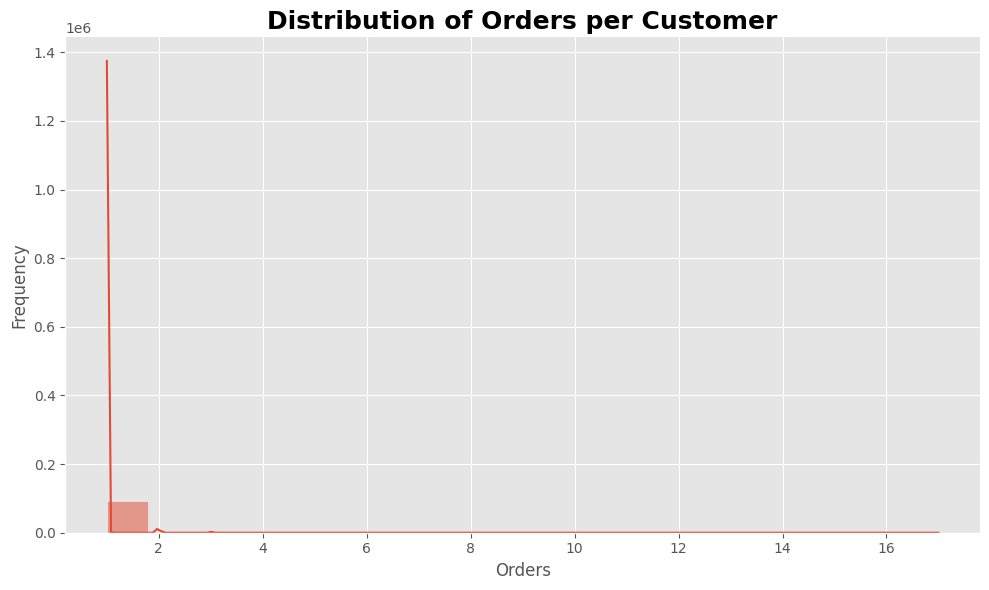

In [28]:
plt.figure(figsize=(10,6))

sns.histplot(
    customer_orders,
    bins=20,
    kde=True
)

plt.title(
    "Distribution of Orders per Customer",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Orders")

plt.ylabel("Frequency")

sns.despine()

plt.tight_layout()

plt.show()

## Business Question 11
## Which states generate the highest revenue?

In [29]:
state_revenue = (
    master_df
    .groupby("customer_state")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

state_revenue

,customer_state,payment_value
0,SP,7726078.35
1,RJ,2795615.67
2,MG,2351221.09
3,RS,1160175.66
4,PR,1079795.49
5,BA,805070.98
6,SC,801276.45
7,GO,520481.65
8,DF,438095.32
9,ES,408611.64


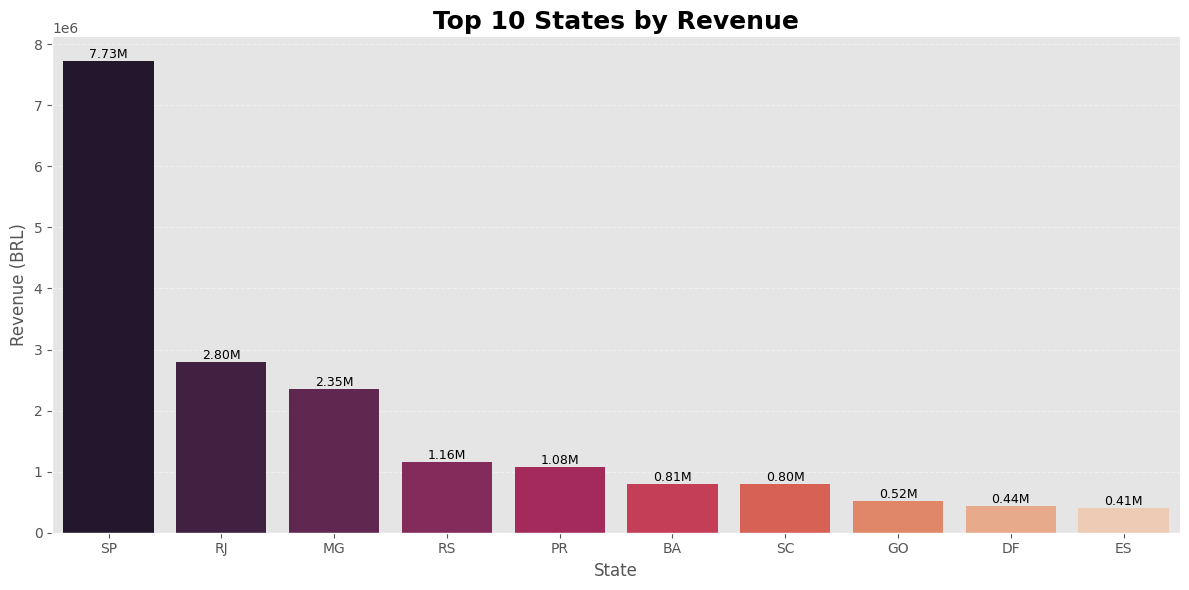

In [30]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=state_revenue,
    x="customer_state",
    y="payment_value",
    palette="rocket"
)

plt.title(
    "Top 10 States by Revenue",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("State")

plt.ylabel("Revenue (BRL)")

for p in ax.patches:
    ax.annotate(
        f'{p.get_height()/1e6:.2f}M',
        (p.get_x()+p.get_width()/2,
         p.get_height()),
        ha="center",
        va="bottom",
        fontsize=9
    )

sns.despine()

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

# Product Analysis

## Objective

Analyze product categories to identify:

- Best-selling categories
- Highest revenue generating categories
- Customer preferences
- Product performance

Business Question 12
Which product categories generate the highest revenue?

In [32]:
master_df.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'purchase_year',
 'purchase_month',
 'purchase_day',
 'purchase_hour',
 'is_weekend',
 'delivery_time',
 'estimated_delivery_time',
 'delivery_delay',
 'late_delivery',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm',
 'seller_zip_code_prefix',
 'seller_city',
 'seller_state',
 'payment_sequential',
 'payment_type',
 'payment_installments',
 'payment_value',
 'review_id',
 'review_score',
 'review_comment_title',
 'review_comment_message',
 'review_creation_date',
 'r

In [33]:
master_df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'purchase_year', 'purchase_month', 'purchase_day', 'purchase_hour',
       'is_weekend', 'delivery_time', 'estimated_delivery_time',
       'delivery_delay', 'late_delivery', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'product_category_name',
       'product_name_lenght', 'product_description_lenght',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm', 'seller_zip_code_prefix',
       'seller_city', 'seller_state', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value', 'review_id', 'review_score',
       'review_comment_tit

In [34]:
category_translation = pd.read_csv("../Data/product_category_name_translation.csv")

In [35]:
master_df = master_df.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

In [36]:
master_df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'purchase_year', 'purchase_month', 'purchase_day', 'purchase_hour',
       'is_weekend', 'delivery_time', 'estimated_delivery_time',
       'delivery_delay', 'late_delivery', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'product_category_name',
       'product_name_lenght', 'product_description_lenght',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm', 'seller_zip_code_prefix',
       'seller_city', 'seller_state', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value', 'review_id', 'review_score',
       'review_comment_tit

In [37]:
master_df.to_csv("../Data/master_dataset.csv", index=False)

In [38]:
category_revenue = (
    master_df
    .groupby("product_category_name_english")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

category_revenue

,product_category_name_english,payment_value
0,bed_bath_table,1743998.80
1,health_beauty,1662963.59
2,computers_accessories,1599481.06
3,furniture_decor,1443963.61
4,watches_gifts,1430553.48
5,sports_leisure,1400223.07
6,housewares,1097900.09
7,auto,855095.68
8,garden_tools,840721.59
9,cool_stuff,781933.97


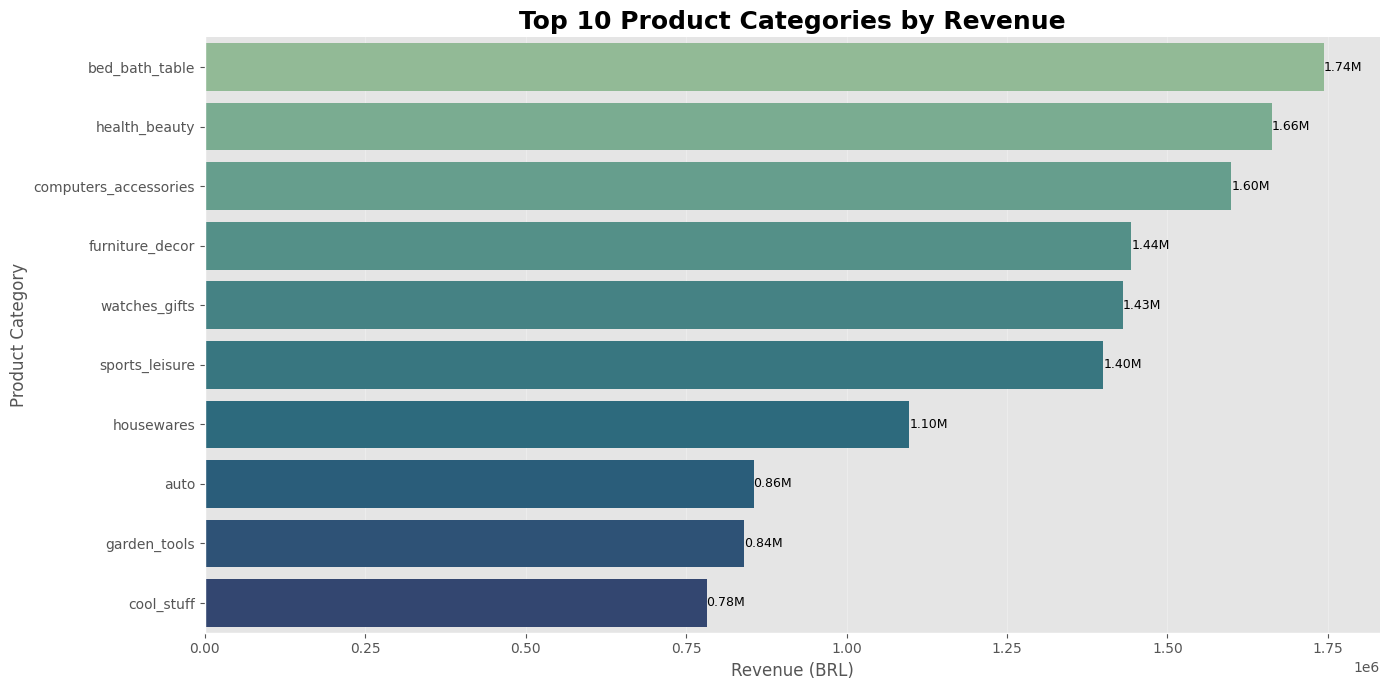

In [39]:
plt.figure(figsize=(14,7))

ax = sns.barplot(
    data=category_revenue,
    y="product_category_name_english",
    x="payment_value",
    palette="crest"
)

plt.title(
    "Top 10 Product Categories by Revenue",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Revenue (BRL)")
plt.ylabel("Product Category")

for p in ax.patches:
    ax.annotate(
        f'{p.get_width()/1e6:.2f}M',
        (p.get_width(), p.get_y()+p.get_height()/2),
        fontsize=9,
        va="center"
    )

plt.grid(axis="x", alpha=0.3)

sns.despine()

plt.tight_layout()

plt.show()

# Business Question 13

## Which product categories have the highest sales volume?

Analyzing sales volume helps identify the most popular product categories.

In [40]:
category_sales = (
    master_df
    .groupby("product_category_name_english")["order_item_id"]
    .count()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

category_sales

,product_category_name_english,order_item_id
0,bed_bath_table,11988
1,health_beauty,10032
2,sports_leisure,9004
3,furniture_decor,8832
4,computers_accessories,8150
5,housewares,7380
6,watches_gifts,6213
7,telephony,4726
8,garden_tools,4590
9,auto,4400


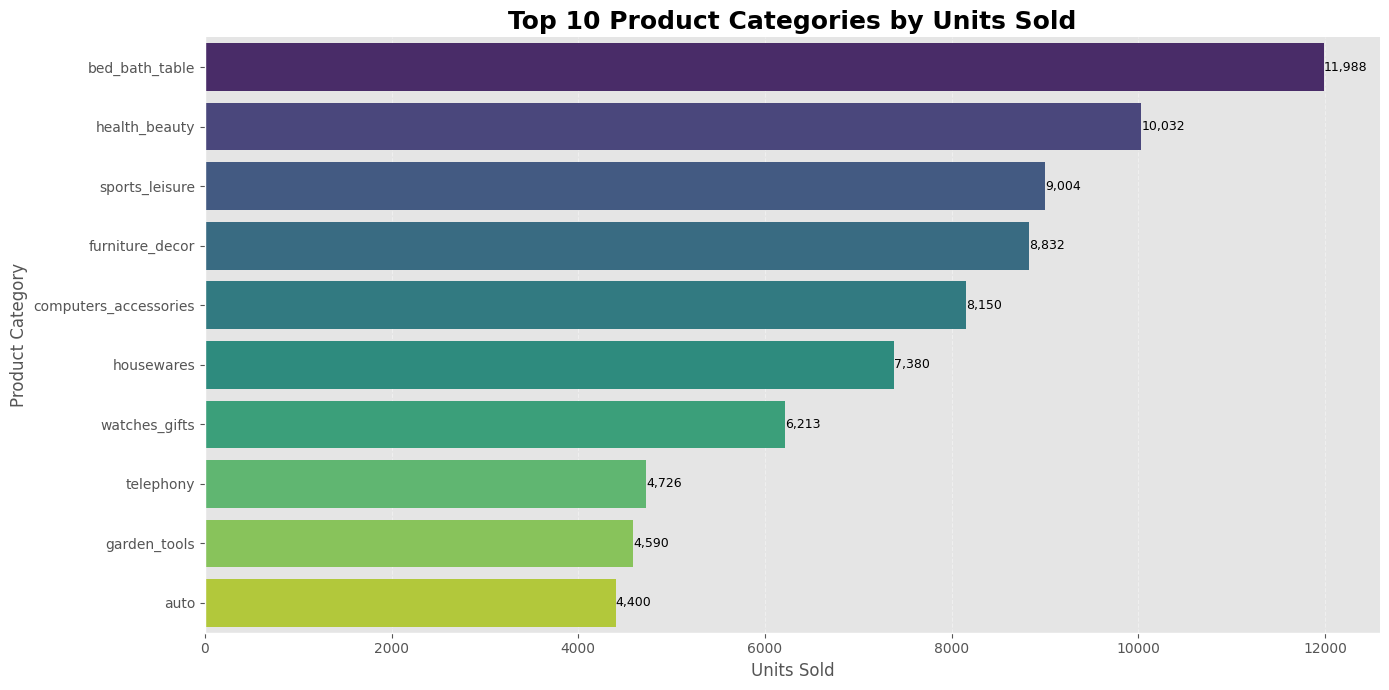

In [41]:
plt.figure(figsize=(14,7))

ax = sns.barplot(
    data=category_sales,
    y="product_category_name_english",
    x="order_item_id",
    palette="viridis"
)

plt.title(
    "Top 10 Product Categories by Units Sold",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Units Sold")
plt.ylabel("Product Category")

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_width()):,}',
        (p.get_width(), p.get_y() + p.get_height()/2),
        ha="left",
        va="center",
        fontsize=9
    )

plt.grid(axis="x", linestyle="--", alpha=0.4)
sns.despine()

plt.tight_layout()
plt.show()

# Business Question 14

## Which product categories receive the highest customer ratings?

Customer ratings help evaluate product quality and customer satisfaction across categories.

In [42]:
category_rating = (
    master_df
    .groupby("product_category_name_english")
    .agg(
        average_rating=("review_score", "mean"),
        total_reviews=("review_score", "count")
    )
    .query("total_reviews >= 100")
    .sort_values("average_rating", ascending=False)
    .head(10)
    .reset_index()
)

category_rating

,product_category_name_english,average_rating,total_reviews
0,books_general_interest,4.438503,561
1,costruction_tools_tools,4.415842,101
2,books_technical,4.375465,269
3,food_drink,4.324138,290
4,luggage_accessories,4.295945,1159
5,food,4.228963,511
6,fashion_shoes,4.223443,273
7,home_appliances_2,4.212687,268
8,pet_shop,4.197030,2020
9,stationery,4.188339,2607


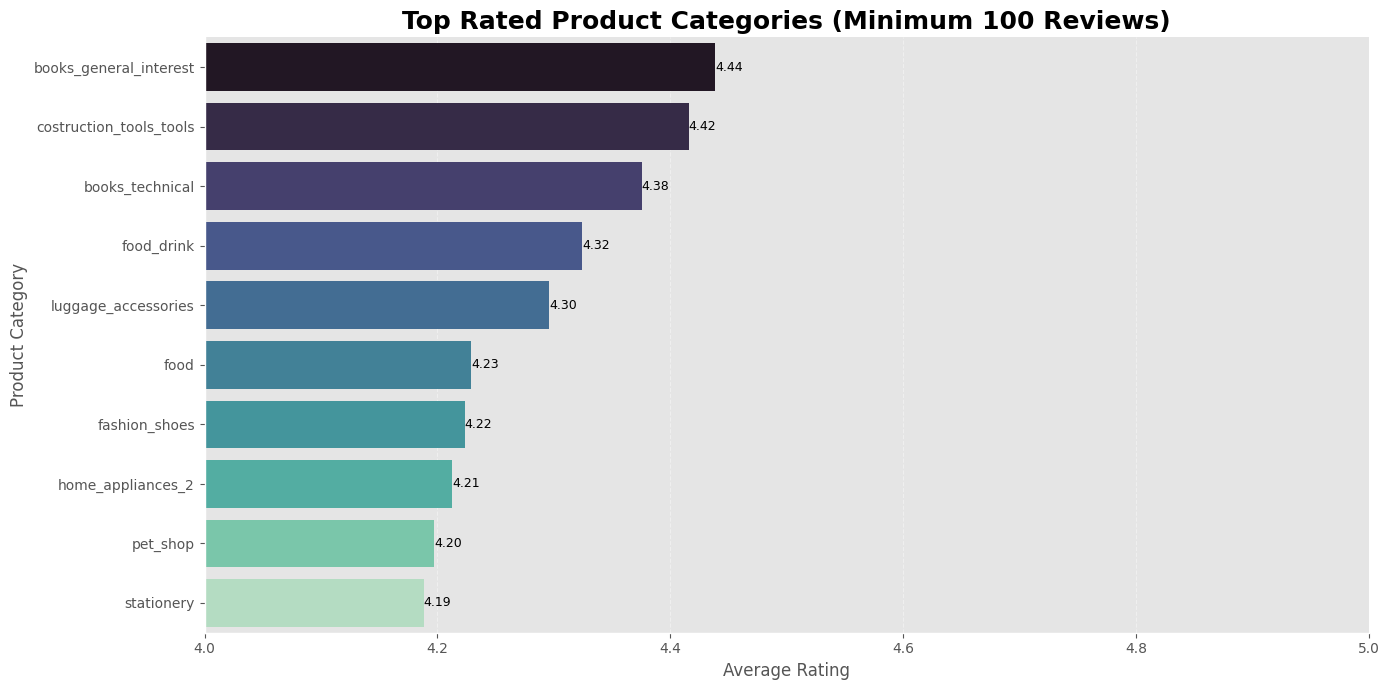

In [43]:
plt.figure(figsize=(14,7))

ax = sns.barplot(
    data=category_rating,
    y="product_category_name_english",
    x="average_rating",
    palette="mako"
)

plt.title(
    "Top Rated Product Categories (Minimum 100 Reviews)",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Average Rating")
plt.ylabel("Product Category")

plt.xlim(4.0, 5.0)

for p in ax.patches:
    ax.annotate(
        f'{p.get_width():.2f}',
        (p.get_width(), p.get_y() + p.get_height()/2),
        ha="left",
        va="center",
        fontsize=9
    )

plt.grid(axis="x", linestyle="--", alpha=0.4)
sns.despine()

plt.tight_layout()
plt.show()

# Business Question 15

## Does product price influence customer ratings?

Analyze whether higher-priced products receive better customer ratings.

In [44]:
sample = master_df[
    ["price", "review_score"]
].dropna().sample(5000, random_state=42)

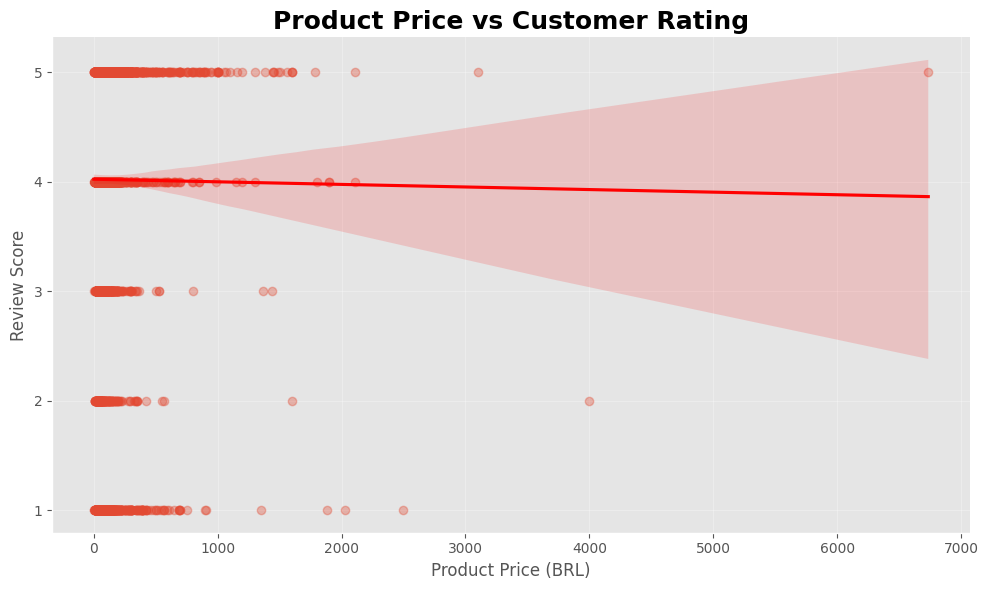

In [45]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=sample,
    x="price",
    y="review_score",
    scatter_kws={"alpha":0.35},
    line_kws={"color":"red"}
)

plt.title(
    "Product Price vs Customer Rating",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Product Price (BRL)")
plt.ylabel("Review Score")

plt.grid(alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

# Delivery & Logistics Analysis

## Objective

Analyze delivery performance to understand:

- Delivery time distribution
- Delivery delays
- Impact of delays on customer satisfaction
- Operational bottlenecks

## Business Question 16
## How long does delivery usually take?

In [46]:
master_df["delivery_time"].describe()

count    115722.000000
mean         12.022589
std           9.454922
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         209.000000
Name: delivery_time, dtype: float64

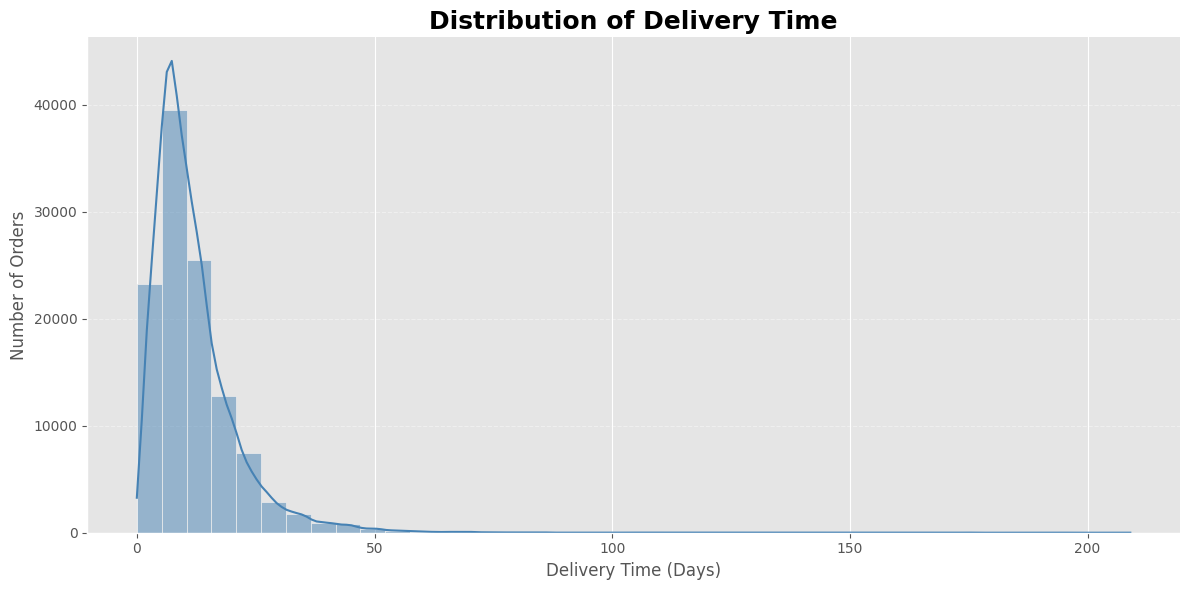

In [47]:
plt.figure(figsize=(12,6))

sns.histplot(
    master_df["delivery_time"].dropna(),
    bins=40,
    kde=True,
    color="steelblue"
)

plt.title(
    "Distribution of Delivery Time",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")

plt.grid(axis="y", linestyle="--", alpha=0.4)
sns.despine()

plt.tight_layout()
plt.show()

## Business Question 17
## How many orders are delivered late?

In [48]:
late_orders = (
    master_df["late_delivery"]
    .value_counts()
    .reset_index()
)

late_orders.columns = ["Late Delivery", "Orders"]

late_orders

,Late Delivery,Orders
0,False,111584
1,True,7559


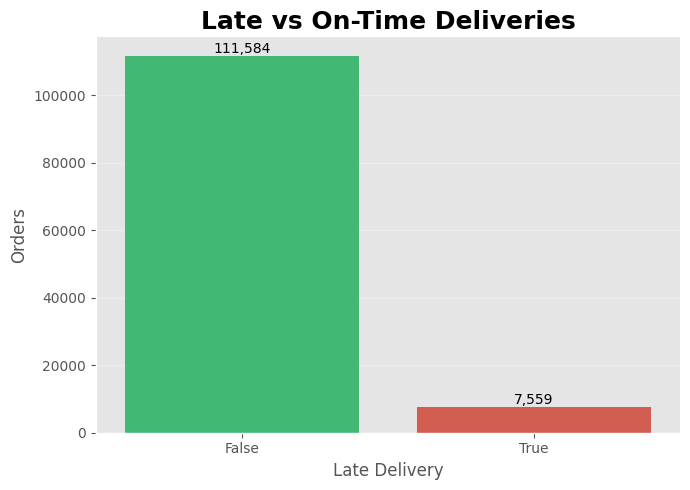

In [49]:
plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=late_orders,
    x="Late Delivery",
    y="Orders",
    palette=["#2ecc71", "#e74c3c"]
)

plt.title(
    "Late vs On-Time Deliveries",
    fontsize=18,
    fontweight="bold"
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',
        (p.get_x()+p.get_width()/2,
         p.get_height()),
        ha='center',
        va='bottom'
    )

plt.grid(axis="y", alpha=.3)

sns.despine()

plt.tight_layout()

plt.show()

## Business Question 18
## Do delivery delays affect customer ratings?

In [56]:
plot_df = master_df[
    (master_df["delivery_delay"].between(-30, 30)) &
    (master_df["review_score"].notna())
]

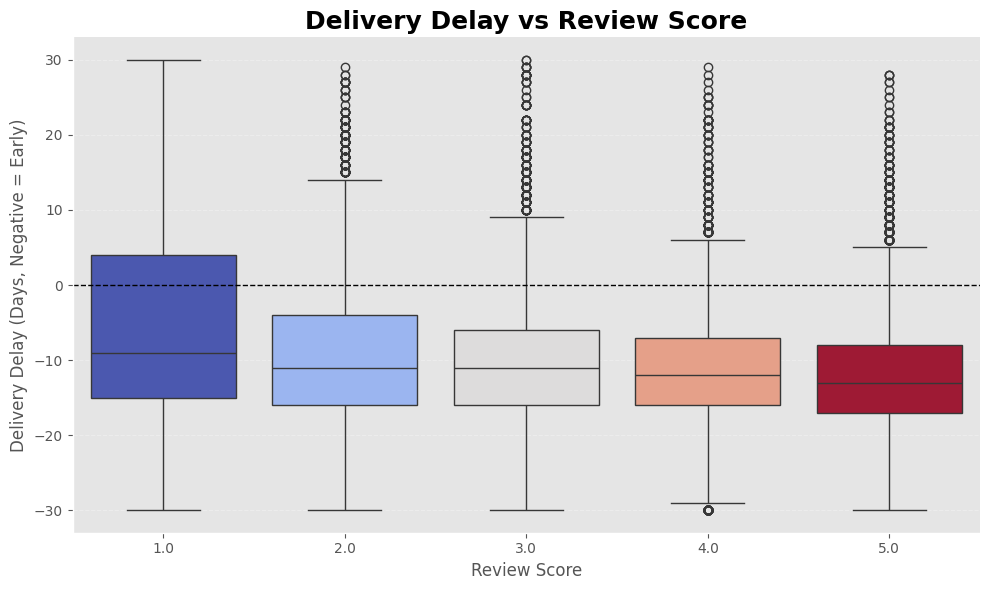

In [57]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=plot_df,
    x="review_score",
    y="delivery_delay",
    hue="review_score",
    palette="coolwarm",
    legend=False
)

plt.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.title(
    "Delivery Delay vs Review Score",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Review Score")
plt.ylabel("Delivery Delay (Days, Negative = Early)")

plt.grid(axis="y", linestyle="--", alpha=0.3)

sns.despine()

plt.tight_layout()

plt.show()

# Business Question 19

## Does delivery time influence customer ratings?

Analyze whether customers tend to give lower ratings as delivery time increases.

In [58]:
plot_df = master_df[
    ["delivery_time", "review_score"]
].dropna()

plot_df = plot_df[
    plot_df["delivery_time"].between(0, 60)
]

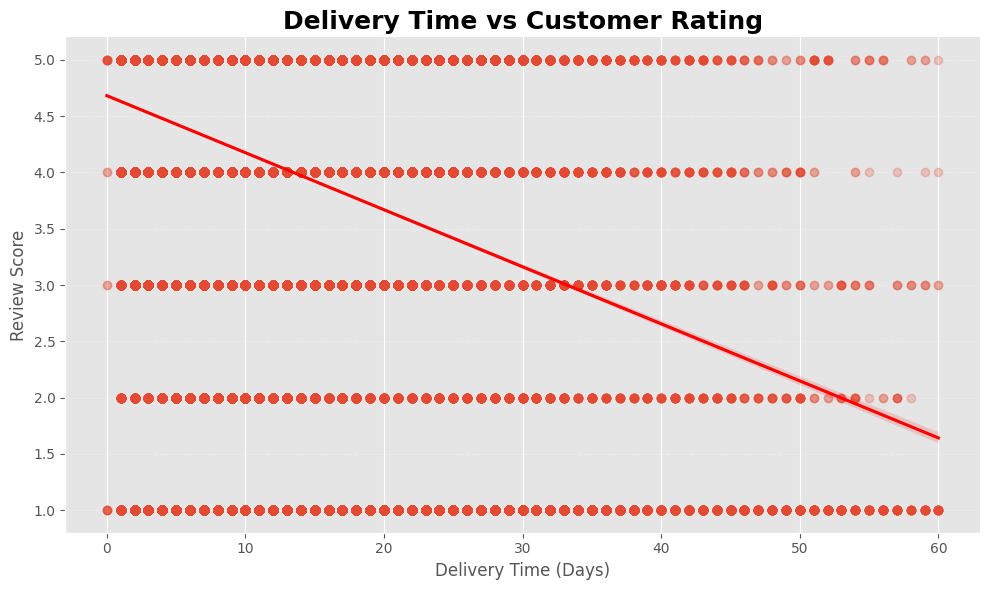

In [59]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=plot_df,
    x="delivery_time",
    y="review_score",
    scatter_kws={"alpha":0.25},
    line_kws={"color":"red"}
)

plt.title(
    "Delivery Time vs Customer Rating",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Delivery Time (Days)")
plt.ylabel("Review Score")

plt.grid(axis="y", linestyle="--", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

# Seller Analysis

## Objective

Analyze seller performance based on:

- Revenue
- Delivery Performance
- Customer Ratings

In [60]:
seller_revenue = (
    master_df
    .groupby("seller_id")
    .agg(
        total_revenue=("payment_value","sum"),
        total_orders=("order_id","nunique")
    )
    .sort_values("total_revenue",ascending=False)
    .head(10)
    .reset_index()
)

seller_revenue

,seller_id,total_revenue,total_orders
0,7c67e1448b00f6e969d365cea6b010ab,512645.19,982
1,1025f0e2d44d7041d6cf58b6550e0bfa,312456.49,915
2,4a3ca9315b744ce9f8e9374361493884,306138.80,1806
3,1f50f920176fa81dab994f9023523100,291918.98,1404
4,53243585a1d6dc2643021fd1853d8905,284903.08,358
5,da8622b14eb17ae2831f4ac5b9dab84a,276578.63,1314
6,4869f7a5dfa277a7dca6462dcf3b52b2,264166.12,1132
7,955fee9216a65b617aa5c0531780ce60,236414.48,1287
8,fa1c13f2614d7b5c4749cbc52fecda94,206513.23,585
9,7e93a43ef30c4f03f38b393420bc753a,185134.21,336


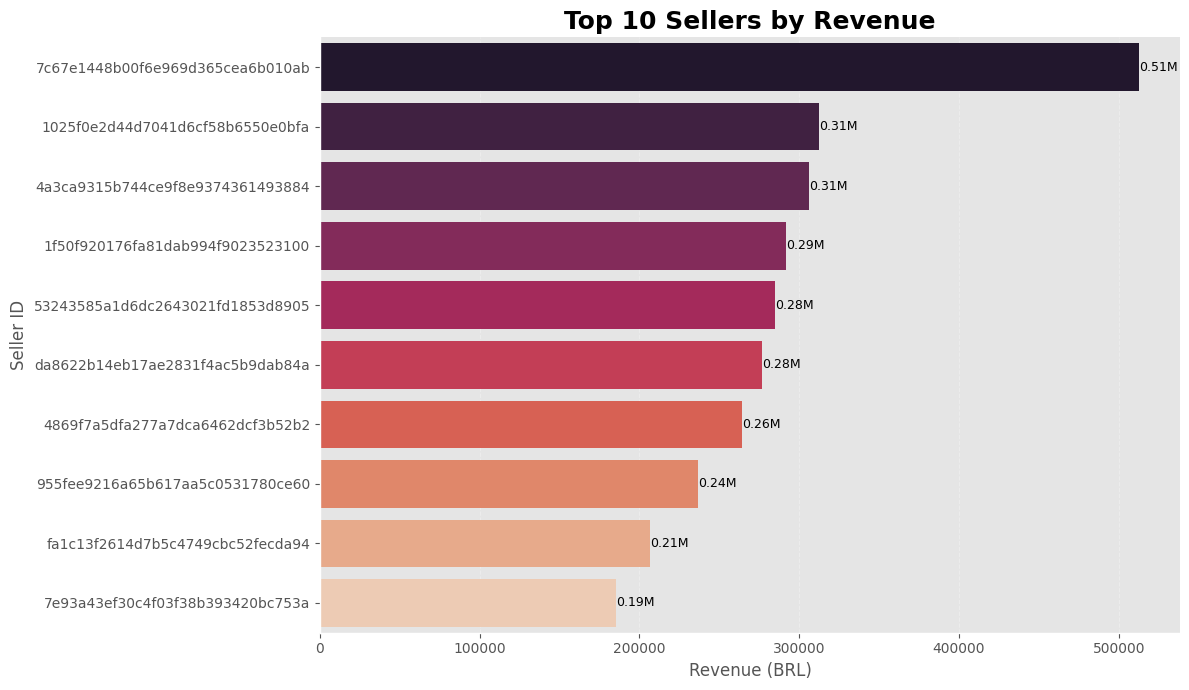

In [61]:
plt.figure(figsize=(12,7))

ax = sns.barplot(
    data=seller_revenue,
    y="seller_id",
    x="total_revenue",
    palette="rocket"
)

plt.title(
    "Top 10 Sellers by Revenue",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Revenue (BRL)")
plt.ylabel("Seller ID")

for p in ax.patches:
    ax.annotate(
        f'{p.get_width()/1e6:.2f}M',
        (p.get_width(), p.get_y()+p.get_height()/2),
        va="center",
        fontsize=9
    )

sns.despine()
plt.grid(axis="x",linestyle="--",alpha=.3)

plt.tight_layout()
plt.show()

In [62]:
seller_delivery = (
    master_df
    .groupby("seller_id")
    .agg(
        avg_delivery_days=("delivery_time","mean"),
        total_orders=("order_id","nunique")
    )
)

seller_delivery = (
    seller_delivery
    .query("total_orders >= 20")
    .sort_values("avg_delivery_days")
    .head(10)
    .reset_index()
)

seller_delivery

,seller_id,avg_delivery_days,total_orders
0,41c2bad7229b0c25e6becf179ebf63ff,4.304348,20
1,d13e50eaa47b4cbe9eb81465865d8cfc,4.585714,67
2,b494891378bd8f4560abe576c52deacd,4.666667,20
3,6b90f847357d8981edd79a1eb1bf0acb,4.882353,45
4,671585f5a2af58b6e276bc01003c0d2b,5.148148,27
5,0885aaf116795758dfeb5f1032487bcd,5.166667,28
6,18e694e0e48ed6f7aa3f24aade5fd697,5.243243,31
7,95ec4458365c4d11f452ccf538377619,5.290323,27
8,d566c37fa119d5e66c4e9052e83ee4ea,5.342466,65
9,bf00385a5f7fc1ef39a13c2e9ee50a5f,5.428571,29


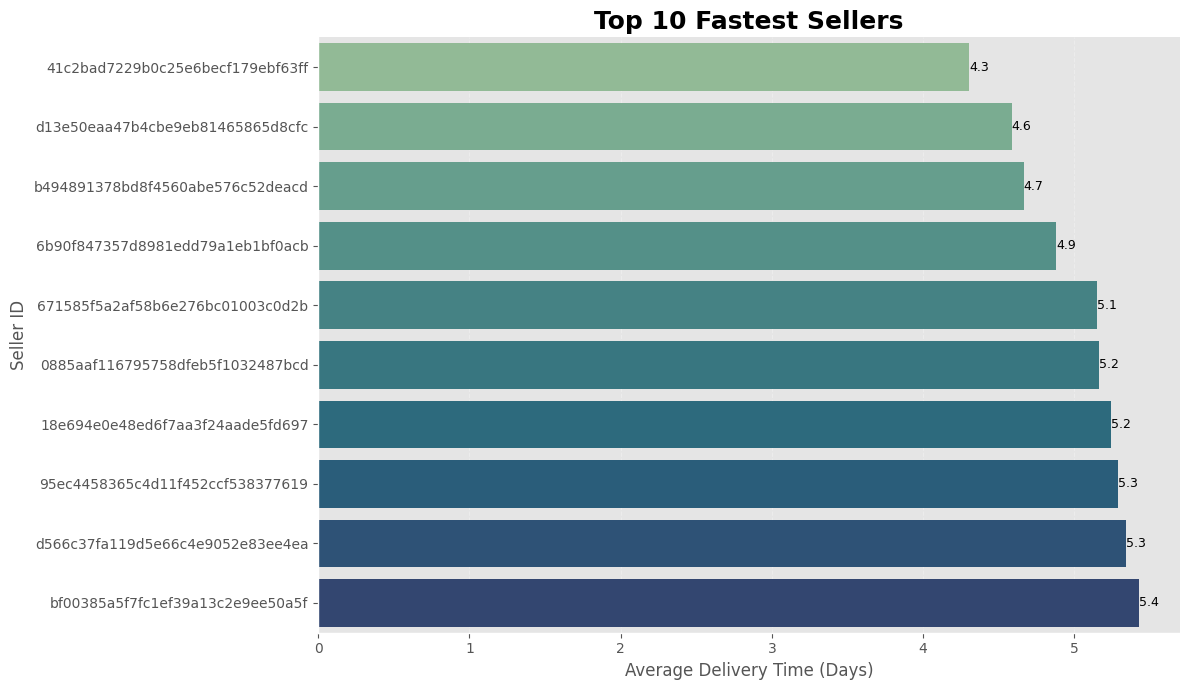

In [63]:
plt.figure(figsize=(12,7))

ax = sns.barplot(
    data=seller_delivery,
    y="seller_id",
    x="avg_delivery_days",
    palette="crest"
)

plt.title(
    "Top 10 Fastest Sellers",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Average Delivery Time (Days)")
plt.ylabel("Seller ID")

for p in ax.patches:
    ax.annotate(
        f'{p.get_width():.1f}',
        (p.get_width(), p.get_y()+p.get_height()/2),
        va="center",
        fontsize=9
    )

sns.despine()
plt.grid(axis="x",linestyle="--",alpha=.3)

plt.tight_layout()
plt.show()

# Payment Analysis

## Objective

Analyze customer payment behavior and installment preferences.

In [64]:
payment_dist = (
    master_df["payment_type"]
    .value_counts(normalize=True)
    *100
)

payment_dist

payment_type
credit_card    73.674668
boleto         19.464496
voucher         5.426389
debit_card      1.431929
not_defined     0.002518
Name: proportion, dtype: float64

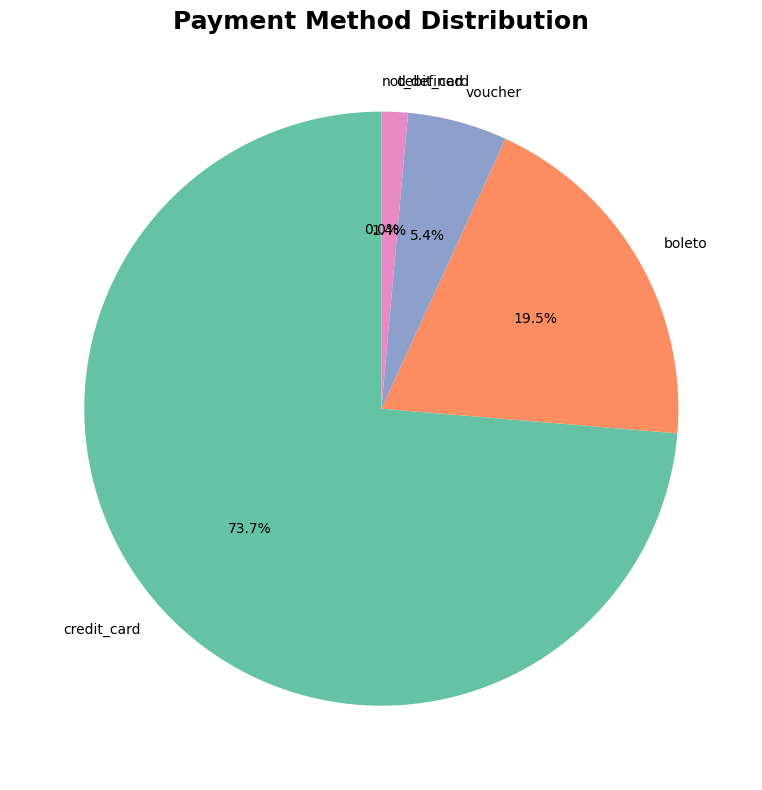

In [65]:
plt.figure(figsize=(8,8))

plt.pie(
    payment_dist.values,
    labels=payment_dist.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("Set2")
)

plt.title(
    "Payment Method Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

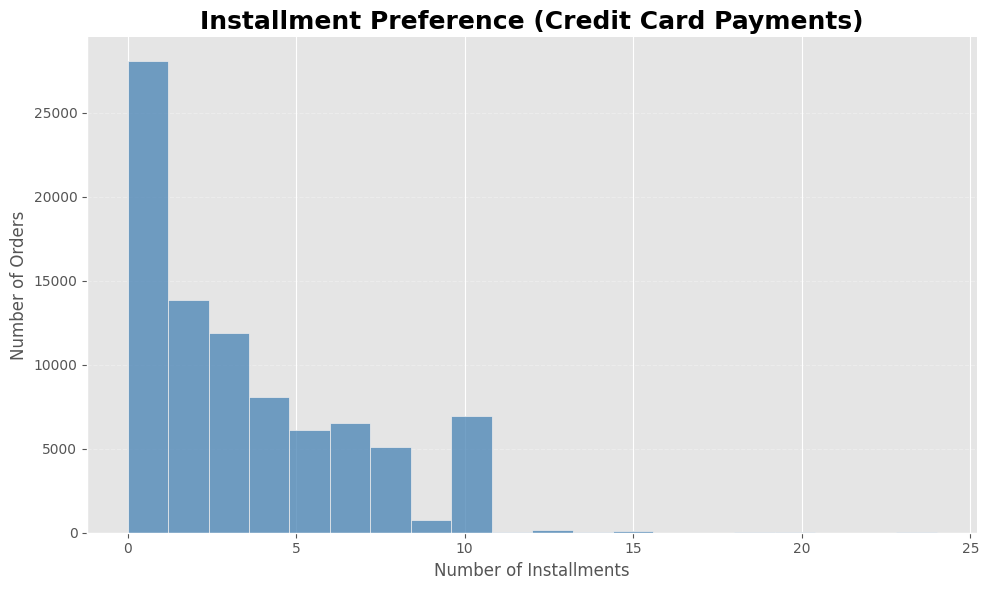

In [66]:
plt.figure(figsize=(10,6))

sns.histplot(
    master_df.loc[
        master_df["payment_type"]=="credit_card",
        "payment_installments"
    ],
    bins=20,
    color="steelblue"
)

plt.title(
    "Installment Preference (Credit Card Payments)",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Number of Installments")
plt.ylabel("Number of Orders")

sns.despine()
plt.grid(axis="y",linestyle="--",alpha=.3)

plt.tight_layout()
plt.show()

# Correlation Analysis

## Business Question 26

### Which business metrics are correlated?

Correlation analysis helps identify relationships between product price, shipping cost, delivery performance, payment amount, and customer satisfaction.

In [67]:
corr_columns = [
    "price",
    "freight_value",
    "payment_value",
    "delivery_time",
    "delivery_delay",
    "review_score"
]

corr_matrix = master_df[corr_columns].corr()

corr_matrix

,price,freight_value,payment_value,delivery_time,delivery_delay,review_score
price,1.000000,0.415938,0.739236,0.061389,-0.003150,-0.004492
freight_value,0.415938,1.000000,0.373762,0.212870,-0.040571,-0.037013
payment_value,0.739236,0.373762,1.000000,0.060449,-0.019448,-0.082343
delivery_time,0.061389,0.212870,0.060449,1.000000,0.598278,-0.302750
delivery_delay,-0.003150,-0.040571,-0.019448,0.598278,1.000000,-0.228449
review_score,-0.004492,-0.037013,-0.082343,-0.302750,-0.228449,1.000000


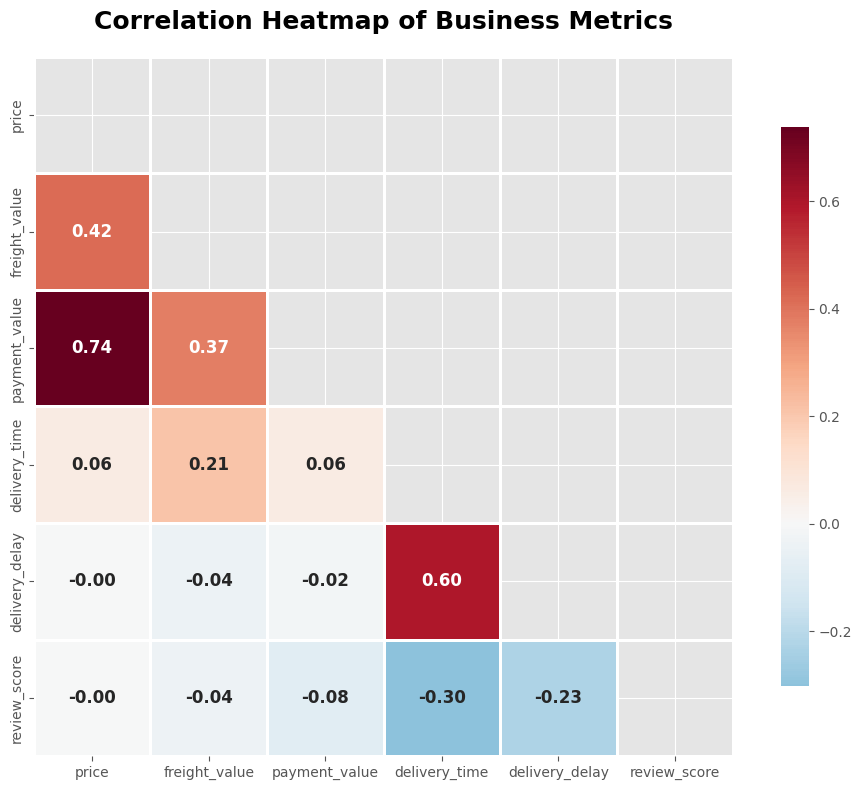

In [69]:
plt.figure(figsize=(10,8))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.8,
    square=True,
    cbar_kws={"shrink":0.8},
    annot_kws={"size":12 , "weight":"bold"}
)

plt.title(
    "Correlation Heatmap of Business Metrics",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()